<a href="https://colab.research.google.com/github/PARTHDEVX2904/MACHINE_LEARNING/blob/main/ML_DAY_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  **10 minutes to pandas**




In [2]:
import pandas as pd
import numpy as np

-Series: a one-dimensional labeled array holding data of any type
such as integers, strings, Python objects etc.

-DataFrame: a two-dimensional data structure that holds data like a two-dimension array or a table with rows and columns.

In [ ]:
 s = pd.Series([1, 3, 5, np.nan, 6, 8])

 s


,0
0,1.0
1,3.0
2,5.0
3,NaN
4,6.0
5,8.0


# **Object creation**

In [4]:
dates = pd.date_range("20130101", periods=6)
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))

print(df


      )

                   A         B         C         D
2013-01-01 -0.179060 -2.257273 -0.915808  0.279085
2013-01-02  1.144065 -1.786405 -1.010218 -1.707512
2013-01-03 -0.202573  0.431267 -1.717054 -0.888567
2013-01-04  0.707453 -0.808770  1.003123 -1.620342
2013-01-05  1.812941 -3.140194 -1.446590 -1.277789
2013-01-06  1.060179  0.173718  0.093968  1.135907


In [5]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)

df2


,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


In [10]:
df2.head()
df2.tail(2)

,A,B,C,D,E,F
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


In [11]:
df2.index

Index([0, 1, 2, 3], dtype='int64')

In [13]:
df2.to_numpy

<bound method DataFrame.to_numpy of      A          B    C  D      E    F
0  1.0 2013-01-02  1.0  3   test  foo
1  1.0 2013-01-02  1.0  3  train  foo
2  1.0 2013-01-02  1.0  3   test  foo
3  1.0 2013-01-02  1.0  3  train  foo>

In [15]:
df2.describe()
df2.T

,0,1,2,3
A,1.0,1.0,1.0,1.0
B,2013-01-02 00:00:00,2013-01-02 00:00:00,2013-01-02 00:00:00,2013-01-02 00:00:00
C,1.0,1.0,1.0,1.0
D,3,3,3,3
E,test,train,test,train
F,foo,foo,foo,foo


However, in programming (like NumPy or Pandas), axis=1 means moving horizontally across columns, and axis=0 means moving vertically down rows.

In [16]:
df2.sort_index(axis=1, ascending=False)

,F,E,D,C,B,A
0,foo,test,3,1.0,2013-01-02,1.0
1,foo,train,3,1.0,2013-01-02,1.0
2,foo,test,3,1.0,2013-01-02,1.0
3,foo,train,3,1.0,2013-01-02,1.0


In [17]:
df2.sort_values(by="B")

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


# **Getitem ([])**

In [20]:
df2["A"]
df2.A
print(len(df2))

4


# **Missing data**

In [22]:
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))
s1 = pd.Series(
   [1, 2, 3, 4, 5, 6],
   index=pd.date_range("20130102", periods=6))
df["F"] = s1
df.loc[:, "D"] = np.array([5] * len(df))
df
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])

df1.loc[dates[0] : dates[1], "E"] = 1
df1

,A,B,C,D,F,E
2013-01-01,0.374924,2.221542,-0.225085,5.0,NaN,1.0
2013-01-02,-0.348972,-0.272146,-0.588071,5.0,1.0,1.0
2013-01-03,0.225682,-1.547801,0.929238,5.0,2.0,NaN
2013-01-04,0.438953,0.708655,0.201008,5.0,3.0,NaN


In [24]:
df1.dropna(how="any")
df1.fillna(value=5)

,A,B,C,D,F,E
2013-01-01,0.374924,2.221542,-0.225085,5.0,5.0,1.0
2013-01-02,-0.348972,-0.272146,-0.588071,5.0,1.0,1.0
2013-01-03,0.225682,-1.547801,0.929238,5.0,2.0,5.0
2013-01-04,0.438953,0.708655,0.201008,5.0,3.0,5.0


In [25]:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


In [26]:
df.mean()

,0
A,0.522508
B,0.205135
C,0.025227
D,5.000000
F,3.000000


In [28]:
s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)
s
df.sub(s, axis="index")

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-0.774318,-2.547801,-0.070762,4.0,1.0
2013-01-04,-2.561047,-2.291345,-2.798992,2.0,0.0
2013-01-05,-3.402531,-4.210112,-5.188651,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


In [29]:
df.agg(lambda x: np.mean(x) * 5.6)

,0
A,2.926042
B,1.148756
C,0.141269
D,28.000000
F,16.800000


In [30]:
df.transform(lambda x: x * 101.2)

,A,B,C,D,F
2013-01-01,37.942332,224.820098,-22.778630,506.0,NaN
2013-01-02,-35.316014,-27.541225,-59.512771,506.0,101.2
2013-01-03,22.839032,-156.637508,94.038927,506.0,202.4
2013-01-04,44.422030,71.715854,20.341980,506.0,303.6
2013-01-05,161.663867,79.936622,-19.091503,506.0,404.8
2013-01-06,85.715333,-67.735914,2.319617,506.0,506.0


# **Value Counts**

In [35]:
s = pd.Series(np.random.randint(0, 7, size=10))
s.value_counts()

,count
3,4
4,2
6,2
0,1
2,1


# **String Methods**

In [36]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])
s.str.lower()

,0
0,a
1,b
2,c
3,aaba
4,baca
5,NaN
6,caba
7,dog
8,cat


# **Merge**

In [38]:
df = pd.DataFrame(np.random.randn(10, 4))
pieces = [df[:3], df[3:7], df[7:]]
pd.concat(pieces)


,0,1,2,3
0,1.791158,0.503084,-0.175809,-0.888406
1,-0.567191,-2.189221,-0.722588,-0.242922
2,1.245582,1.235693,1.446790,-0.819707
3,-0.359029,1.091409,0.950986,0.408744
4,0.510635,1.672832,-0.155566,0.603484
5,0.264712,-1.215161,-0.371435,0.498482
6,0.152062,-0.518212,1.400936,-0.477744
7,-1.962415,0.301245,0.087912,0.478605
8,0.062443,1.621222,-1.828141,-0.510522
9,0.325744,1.068581,0.607439,-0.283373


# **Join**

In [39]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
pd.merge(left, right, on="key")

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


In [40]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
df

,A,B,C,D
0,foo,one,-0.916715,-1.617931
1,bar,one,1.270458,0.794245
2,foo,two,-0.919005,0.705855
3,bar,three,-0.670882,-1.590589
4,foo,two,-1.021319,-0.158788
5,bar,two,-0.049802,1.263136
6,foo,one,-1.345837,1.538828
7,foo,three,-0.315784,1.621940


Grouping by a column label, selecting column labels, and then applying the DataFrameGroupBy.sum() function to the resulting groups:

In [42]:
df.groupby("A")[["C", "D"]].sum()
df.groupby(["A", "B"]).sum()

C         D
A   B                        
bar one    1.270458  0.794245
    three -0.670882 -1.590589
    two   -0.049802  1.263136
foo one   -2.262552 -0.079103
    three -0.315784  1.621940
    two   -1.940324  0.547067

In [ ]:
arrays = [
   ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
   ["one", "two", "one", "two", "one", "two", "one", "two"],
]
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])

In [43]:
df2 = df[:4]
df2

,A,B,C,D
0,foo,one,-0.916715,-1.617931
1,bar,one,1.270458,0.794245
2,foo,two,-0.919005,0.705855
3,bar,three,-0.670882,-1.590589


In [46]:
stacked = df2.stack()
stacked

0  A         foo
   B         one
   C   -0.916715
   D   -1.617931
1  A         bar
   B         one
   C    1.270458
   D    0.794245
2  A         foo
   B         two
   C   -0.919005
   D    0.705855
3  A         bar
   B       three
   C   -0.670882
   D   -1.590589
dtype: object

In [47]:
stacked.unstack()

,A,B,C,D
0,foo,one,-0.916715,-1.617931
1,bar,one,1.270458,0.794245
2,foo,two,-0.919005,0.705855
3,bar,three,-0.670882,-1.590589


In [49]:
stacked.unstack(1)

,A,B,C,D
0,foo,one,-0.916715,-1.617931
1,bar,one,1.270458,0.794245
2,foo,two,-0.919005,0.705855
3,bar,three,-0.670882,-1.590589


In [50]:
stacked.unstack(0)

,0,1,2,3
A,foo,bar,foo,bar
B,one,one,two,three
C,-0.916715,1.270458,-0.919005,-0.670882
D,-1.617931,0.794245,0.705855,-1.590589


In [51]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)
df

,A,B,C,D,E
0,one,A,foo,-1.991189,0.206021
1,one,B,foo,0.147063,-0.847756
2,two,C,foo,-0.081471,0.611093
3,three,A,bar,-0.591106,-0.522178
4,one,B,bar,-0.824831,1.288424
5,one,C,bar,-0.995960,-0.584321
6,two,A,foo,-1.322385,0.214792
7,three,B,foo,-0.540892,-0.902056
8,one,C,foo,0.316094,0.239539
9,one,A,bar,-0.216572,-1.098243


When to use Pivot TablesYou should reach for pd.pivot_table() instead of standard .groupby() when your goal is to:Summarize with Aggregations: Calculate metrics (e.g., sum, mean, max) based on intersecting dimensions.Perform Cross-Tabulation: Place one categorical variable on the rows and another on the columns.Handle Missing Data Easily: Automatically replace empty cells with a specific value using the fill_value parameter.Calculate Totals: Add overall totals/averages for both rows and columns using margins=True.

In [52]:
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])


C             bar       foo
A     B                    
one   A -0.216572 -1.991189
      B -0.824831  0.147063
      C -0.995960  0.316094
three A -0.591106       NaN
      B       NaN -0.540892
      C -1.057807       NaN
two   A       NaN -1.322385
      B -0.463607       NaN
      C       NaN -0.081471

# **Time series**

In [3]:
rng = pd.date_range("1/1/2012", periods=100, freq="s")
print(rng)

DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 00:00:01',
               '2012-01-01 00:00:02', '2012-01-01 00:00:03',
               '2012-01-01 00:00:04', '2012-01-01 00:00:05',
               '2012-01-01 00:00:06', '2012-01-01 00:00:07',
               '2012-01-01 00:00:08', '2012-01-01 00:00:09',
               '2012-01-01 00:00:10', '2012-01-01 00:00:11',
               '2012-01-01 00:00:12', '2012-01-01 00:00:13',
               '2012-01-01 00:00:14', '2012-01-01 00:00:15',
               '2012-01-01 00:00:16', '2012-01-01 00:00:17',
               '2012-01-01 00:00:18', '2012-01-01 00:00:19',
               '2012-01-01 00:00:20', '2012-01-01 00:00:21',
               '2012-01-01 00:00:22', '2012-01-01 00:00:23',
               '2012-01-01 00:00:24', '2012-01-01 00:00:25',
               '2012-01-01 00:00:26', '2012-01-01 00:00:27',
               '2012-01-01 00:00:28', '2012-01-01 00:00:29',
               '2012-01-01 00:00:30', '2012-01-01 00:00:31',
               '2012-01-

In [2]:
import numpy as np
import pandas as pd

In [6]:
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts.resample("5Min").sum()

,0
2012-01-01,26136


In [10]:
rng = pd.date_range("3/6/2012 00:00", periods=5, freq="D")

ts = pd.Series(np.random.randn(len(rng)), rng)

ts_utc = ts.tz_localize("UTC")
ts_utc

,0
2012-03-06 00:00:00+00:00,1.497017
2012-03-07 00:00:00+00:00,-0.193995
2012-03-08 00:00:00+00:00,0.259791
2012-03-09 00:00:00+00:00,-0.124706
2012-03-10 00:00:00+00:00,0.802830


In [12]:
rng
rng + pd.offsets.BusinessDay(5)


DatetimeIndex(['2012-03-13', '2012-03-14', '2012-03-15', '2012-03-16',
               '2012-03-16'],
              dtype='datetime64[ns]', freq=None)

# **Categoricals**

In [14]:
df = pd.DataFrame(
    {"id": [1, 2, 3, 4, 5, 6], "raw_grade": ["a", "b", "b", "a", "a", "e"]}
)
df["grade"] = df["raw_grade"].astype("category")

df["grade"]

,grade
0,a
1,b
2,b
3,a
4,a
5,e


In [16]:
new_categories = ["very good", "good", "very bad"]

df["grade"] = df["grade"].cat.rename_categories(new_categories)
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]
)
df["grade"]

,grade
0,very good
1,good
2,good
3,very good
4,very good
5,very bad


In [17]:
df.sort_values(by="grade")

,id,raw_grade,grade
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


In [18]:
df.groupby("grade", observed=False).size()

,0
grade,
very bad,1
bad,0
medium,0
good,2
very good,3


# **Plotting**

In [19]:
import matplotlib.pyplot as plt
plt.close("all")

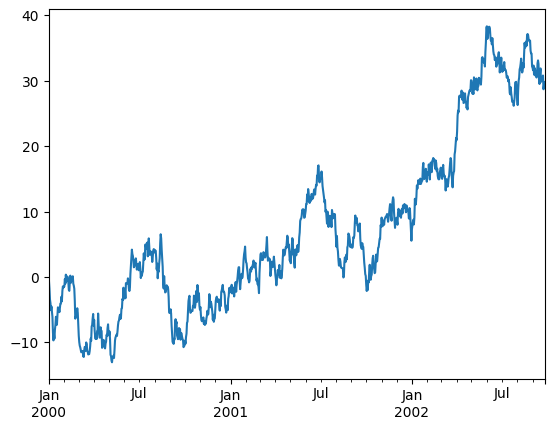

In [20]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))

ts = ts.cumsum()
ts.plot();

# **Importing and exporting data**


In [23]:
df = pd.DataFrame(np.random.randint(0, 5, (10, 5)))

df.to_csv("foo.csv")
print(pd.read_csv("foo.csv"))

   Unnamed: 0  0  1  2  3  4
0           0  3  2  3  1  1
1           1  2  3  4  0  3
2           2  2  4  3  3  0
3           3  4  2  1  2  2
4           4  3  1  4  0  0
5           5  1  4  2  4  1
6           6  0  1  4  2  3
7           7  0  2  2  0  0
8           8  3  4  2  3  2
9           9  1  0  2  3  1


In [ ]:
df.to_parquet("foo.parquet")
pd.read_parquet("foo.parquet")

In [26]:
df.to_excel("foo.xlsx", sheet_name="Sheet1")
pd.read_excel("foo.xlsx", "Sheet1", index_col=None, na_values=["NA"])

,Unnamed: 0,0,1,2,3,4
0,0,3,2,3,1,1
1,1,2,3,4,0,3
2,2,2,4,3,3,0
3,3,4,2,1,2,2
4,4,3,1,4,0,0
5,5,1,4,2,4,1
6,6,0,1,4,2,3
7,7,0,2,2,0,0
8,8,3,4,2,3,2
9,9,1,0,2,3,1
